In [392]:
import seaborn
import pandas 
import base
import observer
import attrib
import stores
import numpy
import geopandas
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import calendar
from datetime import datetime
import h5py
from datetime import datetime, timedelta
from xlsxwriter import Workbook

****NOTE: DPU STEM / LEAF / FRUIT / ROOT concentrations have NA values between the harvest and planting dates. For LINE CHART display purposes, this code by default will insert a 0 concentration value the day after harvest (date extracted from input datastore/hdf5 file).

In [393]:
#Input the local path to the datastore/hdf5 file of interest
#data_store_path = "E:\\Bayer\\bay.18\\models\\xKnowRes_20240315\\run\\TestRun_xKnowRes\\mcs\\X3WD9SKFALFH0YPN74\\store" 
data_store_path = "E:\\Bayer\\bay.18\\models\\xKnowRes230822\\run\\TestRun_xKnowRes\\mcs\\X3UDQO3DQEVSMR85MU\\store"   



#Define path for output folder on local machine
output_folder = "f:\\xknowres_example_plots\\"



# Select an output file format for the data
output_format = ".xlsx"  # ".xlsx"  or  ".csv" or  "none"

# Would you like the raw or summarized datasets?  (Note: summarized data significantly smaller, all fields merged into single value per day per parameter)   
output_tables = "summarized"  # "summarized"  or  "raw"

# Would you like to include the weather data? 
weather_output = "yes"  # "yes"  or  "no"

Names of datasets to select from:
"Dpu/ConcentrationInFruits"
"Dpu/ConcentrationInStems"
"Dpu/ConcentrationInLeaves"
"Dpu/ConcentrationInRoots"
"Pearl/AmaUptPro" 
"Pearl/AmaSysPro"

If additional datasets are desired, add them as additional variables and continue with the current variable definition structure. (i.e. name_of_dataset5 = "Dpu/ConcentrationInStems")

In [435]:
### Comment/uncomment the variables you would like to plot or create a csv of

name_of_dataset1 = "Dpu/ConcentrationInStems"
name_of_dataset2 = "Dpu/ConcentrationInFruits"
name_of_dataset3 = "Dpu/ConcentrationInLeaves"
name_of_dataset4 = "Dpu/ConcentrationInRoots"

weather_var = "Weather/TEMPERATURE_AVG" # can set to "Weather/PRECIPITATION" or "Weather/TEMPERATURE_AVG"
first_day_of_weather_data = "1979-01-01" ## please paste this from weather.xml file



#########################################################################################################################################
### Do not change these options yet, functionality not prepared


###To plot an individual field, select based on "field_idx"
#single_field_idx = 1



########################
###      PLOT 1      ###
########################

#plot1_x = "Time"  # Can set as "Time" or any of the other datasets selected above

###Make sure selected variables on single axis have compatible units!
#plot1_y = ["Dpu/ConcentrationInFruits", "Dpu/ConcentrationInStems", "Dpu/ConcentrationInLeaves", "Dpu/ConcentrationInRoots"]  # Can list 1 or more of the datasets selected above


#plot1_stats = "5 50 95 centile" ### "5 50 95 centile" or choose a field id number (i.e. "78")


**    END OF USER INPUTS    **

In [395]:
def subdata_name(input_string):
    parts = input_string.split('/')
    if len(parts) > 1:
        return parts[1]
    else:
        return input_string
    
def group_name(input_string):
    parts = input_string.split('/')
    if len(parts) > 1:
        return parts[0]
    else:
        return input_string


In [396]:
annual_harvest = base.Input(
    "CropHarvest",
    (attrib.Class(numpy.ndarray), attrib.Scales("global")),
    observer.ConsoleObserver(print_output=True),
    base.Output(
        "Swap/CropHarvest",
        stores.X3dfStore(data_store_path, mode="r")
    )
).read()

annual_harvest_array = numpy.array([annual_harvest.values])

# Convert datetime.date objects to strings
annual_harvest_values = annual_harvest_array.astype(str)

flattened_values = numpy.c_[
    numpy.arange(len(annual_harvest_values)),  
    annual_harvest_values.flatten()
]

harvest_day = flattened_values[0][1]

WARN  Input CropHarvest does not specify its physical unit

NOTE  Input CropHarvest is missing a detailed description

WARN  CropHarvest:ClassChecker:GetValues

      Values are of type <class 'str'>, not of type <class 'numpy.ndarray'>

OK    CropHarvest:ScalesChecker:GetValues

      Values have scales global



In [397]:
start_date = base.Input(
    "SimulationStart",
    (attrib.Class(numpy.ndarray), attrib.Scales("global")),
    observer.ConsoleObserver(print_output=True),
    base.Output(
        "PPM/SimulationStart",
        stores.X3dfStore(data_store_path, mode="r")
    )
).read()

start_date_array = numpy.array([start_date.values])

# Convert datetime.date objects to strings
start_date_values = start_date_array.astype(str)

flattened_start_date = numpy.c_[
    numpy.arange(len(start_date_values)),  
    start_date_values.flatten()
]

start_day = flattened_start_date[0][1]
print(start_day)

WARN  Input SimulationStart does not specify its physical unit

NOTE  Input SimulationStart is missing a detailed description

WARN  SimulationStart:ClassChecker:GetValues

      Values are of type <class 'datetime.date'>, not of type <class 'numpy.ndarray'>

OK    SimulationStart:ScalesChecker:GetValues

      Values have scales global

2013-01-01


In [398]:
end_date = base.Input(
    "SimulationEnd",
    (attrib.Class(numpy.ndarray), attrib.Scales("global")),
    observer.ConsoleObserver(print_output=True),
    base.Output(
        "PPM/SimulationEnd",
        stores.X3dfStore(data_store_path, mode="r")
    )
).read()

end_date_array = numpy.array([end_date.values])

# Convert datetime.date objects to strings
end_date_values = end_date_array.astype(str)

flattened_end_date = numpy.c_[
    numpy.arange(len(end_date_values)),  
    end_date_values.flatten()
]

end_day = flattened_end_date[0][1]
print(end_day)

WARN  Input SimulationEnd does not specify its physical unit

NOTE  Input SimulationEnd is missing a detailed description

WARN  SimulationEnd:ClassChecker:GetValues

      Values are of type <class 'datetime.date'>, not of type <class 'numpy.ndarray'>

OK    SimulationEnd:ScalesChecker:GetValues

      Values have scales global

2016-12-31


##     SET UP WEATHER DATA 

In [399]:
weather_names = ["Weather/PRECIPITATION", "Weather/TEMPERATURE_AVG"]

In [400]:
def get_units_for_datasets(hdf5_file, weather_names):
    weather_dict = {name: None for name in weather_names}

    def check_and_store_units(hdf5_group, parent_group=''):
        nonlocal weather_dict
        for key in hdf5_group.keys():
            if isinstance(hdf5_group[key], h5py.Group):
                check_and_store_units(hdf5_group[key], f"{parent_group}/{key}")
            else:
                dataset_path = f"{parent_group}/{key}"
                for name in weather_names:
                    if dataset_path.endswith(name):
                        dataset = hdf5_group[key]
                        if 'unit' in dataset.attrs:
                            unit = dataset.attrs['unit']
                            scale = dataset.attrs.get('scales', None)  # Get the 'scale' attribute
                            weather_dict[name] = (unit, scale)

    check_and_store_units(hdf5_file)
    return weather_dict

arrdat_path = data_store_path+"\\arr.dat"

with h5py.File(arrdat_path, 'r') as hdf5_file:
    weather_dict = get_units_for_datasets(hdf5_file, weather_names)

#print(weather_dict)

In [401]:
# Get the names of variables defined at the top of the code
top_variables = [value for name, value in locals().items() if isinstance(value, str)]

# Filter the units_dict based on the top variable names
selected_weather= {key: value for key, value in weather_dict.items() if key in top_variables}

#print(selected_weather)

In [402]:
weather_dict = {key: (value[0], list(value[1])) for key, value in selected_weather.items()}

for key, (unit, values) in weather_dict.items():
    # Join the values with comma and space
    values_str = ', '.join(values)
    weather_dict[key] = (unit, values_str)


for key, value in weather_dict.items():
    print("Key:", key)
    print("Value:", value)

weather_keys = weather_dict.keys()

weather_keys = list(map(subdata_name, weather_keys))

print(weather_keys)

Key: Weather/TEMPERATURE_AVG
Value: ('°C', 'time/day, space/weather_region')
['TEMPERATURE_AVG']


In [403]:
with h5py.File(arrdat_path, 'r') as file:
    
    dfs = []

    datasets_to_extract = ["TEMPERATURE_AVG", "PRECIPITATION"] # List of datasets to extract

    for dataset_name in datasets_to_extract:
        dataset = file[f'Weather/{dataset_name}']
        data = numpy.array(dataset)

        # Extract timestamp info
        timestamp_units = dataset.attrs['scales']
        timestamp_units_list = timestamp_units[0].split(',')
        timestamp_unit = timestamp_units_list[0].split('/')[0].strip()  

        # Extract start date if available
        start_date_str = None
        if len(timestamp_units_list) > 1 and '=' in timestamp_units_list[1]:
            start_date_str = timestamp_units_list[1].split('=')[1].strip()  # Extract start date from units attribute
        
        # Parse start date if available
        if start_date_str:
            start_date = datetime.strptime(start_date_str, "%Y-%m-%d")  # Parse start date string
        else:
            start_date = datetime.strptime(first_day_of_weather_data, "%Y-%m-%d")  # Default to date defined by user

        # Generate dates from timestamps
        dates = [start_date + pandas.DateOffset(days=i) for i in range(len(data))]

        if len(data.shape) == 2:
            df = pandas.DataFrame(data, columns=[f"{dataset_name}_{i}" for i in range(data.shape[1])])  # For 2D datasets
        else:
            df = pandas.DataFrame(data, columns=[dataset_name])  # For 1D datasets

        # Add dates column
        df['Date'] = dates
        
        dfs.append(df)

weather_merged = pandas.concat(dfs, axis=1)

print(weather_merged)

       TEMPERATURE_AVG_0  TEMPERATURE_AVG_1       Date  PRECIPITATION_0  \
0                  -14.6              -13.6 1979-01-01              0.1   
1                  -12.8              -11.9 1979-01-02              1.3   
2                  -10.3               -9.5 1979-01-03              0.2   
3                  -11.3              -10.6 1979-01-04              0.0   
4                  -14.0              -13.1 1979-01-05              0.0   
...                  ...                ...        ...              ...   
16066                2.9                4.0 2022-12-27              0.2   
16067                4.8                5.3 2022-12-28              1.3   
16068                8.6                9.7 2022-12-29              1.2   
16069                4.7                6.0 2022-12-30              2.7   
16070               11.4               12.0 2022-12-31              0.0   

       PRECIPITATION_1       Date  
0                  0.2 1979-01-01  
1                  1.0 1979

In [404]:
weather_merged = weather_merged.loc[:,~weather_merged.columns.duplicated()].copy()


# Convert "start_day" and "end_day" to datetime 
start_day = numpy.datetime64(start_day)
end_day = numpy.datetime64(end_day)

# Convert the "Date" to datetime 
weather_merged['Date'] = pandas.to_datetime(weather_merged['Date'])

# Filter rows based on date range
filtered_weather = weather_merged[(weather_merged['Date'] >= start_day) & (weather_merged['Date'] <= end_day)]
print(filtered_weather)

       TEMPERATURE_AVG_0  TEMPERATURE_AVG_1       Date  PRECIPITATION_0  \
12419                5.4                6.8 2013-01-01              3.1   
12420                2.7                3.4 2013-01-02              0.4   
12421                4.5                5.2 2013-01-03              1.1   
12422                8.3                8.9 2013-01-04              1.0   
12423                7.6                8.4 2013-01-05              0.2   
...                  ...                ...        ...              ...   
13875                4.0                4.7 2016-12-27              0.0   
13876                4.1                5.2 2016-12-28              0.0   
13877                1.4                1.9 2016-12-29              0.0   
13878               -2.7               -2.1 2016-12-30              0.0   
13879               -5.1               -4.3 2016-12-31              0.0   

       PRECIPITATION_1  
12419              3.3  
12420              0.2  
12421              1.5  

In [405]:
# Filter columns containing temperature and precipitation
temp_cols = filtered_weather.filter(like='TEMPERATURE_AVG').columns
precip_cols = filtered_weather.filter(like='PRECIPITATION').columns

weather_merged2 = pandas.DataFrame()

# Store the first date column
first_date_column = filtered_weather.filter(like='Date').columns[0]
weather_merged2['Date'] = filtered_weather[first_date_column]

# Calculate avg temp and precip across full scenario/all fields
weather_merged2['TEMPERATURE_AVG'] = filtered_weather[temp_cols].mean(axis=1)
weather_merged2['PRECIPITATION'] = filtered_weather[precip_cols].mean(axis=1)

print(weather_merged2)

            Date  TEMPERATURE_AVG  PRECIPITATION
12419 2013-01-01             6.10           3.20
12420 2013-01-02             3.05           0.30
12421 2013-01-03             4.85           1.30
12422 2013-01-04             8.60           0.85
12423 2013-01-05             8.00           0.25
...          ...              ...            ...
13875 2016-12-27             4.35           0.05
13876 2016-12-28             4.65           0.00
13877 2016-12-29             1.65           0.00
13878 2016-12-30            -2.40           0.00
13879 2016-12-31            -4.70           0.00

[1461 rows x 3 columns]


##     SET UP CONCENTRATION DATA

In [406]:
dataset_names = ["Dpu/ConcentrationInFruits", "Dpu/ConcentrationInStems", "Dpu/ConcentrationInLeaves", "Dpu/ConcentrationInRoots", "Pearl/AmaUptPro"]

In [407]:
def get_units_for_datasets(hdf5_file, dataset_names):
    units_dict = {name: None for name in dataset_names}

    def check_and_store_units(hdf5_group, parent_group=''):
        nonlocal units_dict
        for key in hdf5_group.keys():
            if isinstance(hdf5_group[key], h5py.Group):
                check_and_store_units(hdf5_group[key], f"{parent_group}/{key}")
            else:
                dataset_path = f"{parent_group}/{key}"
                for name in dataset_names:
                    if dataset_path.endswith(name):
                        dataset = hdf5_group[key]
                        if 'unit' in dataset.attrs:
                            unit = dataset.attrs['unit']
                            scale = dataset.attrs.get('scales', None)  # Get the 'scales' attribute
                            units_dict[name] = (unit, scale)

    check_and_store_units(hdf5_file)
    return units_dict


arrdat_path = data_store_path+"\\arr.dat"

with h5py.File(arrdat_path, 'r') as hdf5_file:
    units_dict = get_units_for_datasets(hdf5_file, dataset_names)

#print(units_dict)
#type(units_dict)

In [408]:
# Get the names of variables defined at the top of the code
top_variables = [value for name, value in locals().items() if isinstance(value, str)]

# Filter the units_dict based on the top variable names
filtered_units = {key: value for key, value in units_dict.items() if key in top_variables}

print(filtered_units)

{'Dpu/ConcentrationInFruits': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInStems': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInLeaves': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object)), 'Dpu/ConcentrationInRoots': ('mg/kg', array(['space/base_geometry', 'time/day'], dtype=object))}


In [409]:
dataset_dict = {key: (value[0], list(value[1])) for key, value in filtered_units.items()}


# for key, value in dataset_dict.items():
#     print(f"Key: {key}")
#     print(f"Value: {value}")

In [410]:
for key, (unit, values) in dataset_dict.items():
    # Join the values with comma and space
    values_str = ', '.join(values)
    dataset_dict[key] = (unit, values_str)

for key, value in dataset_dict.items():
    print("Key:", key)
    print("Value:", value)

Key: Dpu/ConcentrationInFruits
Value: ('mg/kg', 'space/base_geometry, time/day')
Key: Dpu/ConcentrationInStems
Value: ('mg/kg', 'space/base_geometry, time/day')
Key: Dpu/ConcentrationInLeaves
Value: ('mg/kg', 'space/base_geometry, time/day')
Key: Dpu/ConcentrationInRoots
Value: ('mg/kg', 'space/base_geometry, time/day')


In [411]:
# Initialize an empty list to store datasets
list_of_datasets = []

for key, (first_value, second_value) in dataset_dict.items():
    dataset = base.Input(
        subdata_name(key),
        (attrib.Class(numpy.ndarray), attrib.Unit(first_value), attrib.Scales(second_value)),
        observer.ConsoleObserver(print_output=True),
        base.Output(
            key,
            stores.X3dfStore(data_store_path, mode="r")
        )
    ).read()
    
    list_of_datasets.append(dataset)

NOTE  Input ConcentrationInFruits is missing a detailed description

OK    ConcentrationInFruits:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInFruits:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInFruits:ScalesChecker:GetValues

      Values have scales space/base_geometry, time/day

NOTE  Input ConcentrationInStems is missing a detailed description

OK    ConcentrationInStems:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInStems:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInStems:ScalesChecker:GetValues

      Values have scales space/base_geometry, time/day

NOTE  Input ConcentrationInLeaves is missing a detailed description

OK    ConcentrationInLeaves:ClassChecker:GetValues

      Values are of type <class 'numpy.ndarray'>

OK    ConcentrationInLeaves:UnitChecker:GetValues

      Values have unit mg/kg

OK    ConcentrationInLeaves:Sc

In [412]:
#len(list_of_datasets)
hdf5_dataset_1 = list_of_datasets[1]
#print(hdf5_dataset_1)

In [413]:
dfs = []


# Iterate through each dataset in list_of_datasets
for dataset, (key, _) in zip(list_of_datasets, dataset_dict.items()):
    # Create DataFrame for the current dataset
    df = pandas.DataFrame(
        numpy.c_[
            numpy.argwhere(dataset.values > 0),
            dataset.values[dataset.values > 0]
            
            
            
            ### keeping this incase it is of interest to return all values instead of filtering
            #numpy.argwhere(numpy.ones_like(datasets_of_interest.values)),             
            #datasets_of_interest.values.flatten()
        ],
        columns=("field_idx", "time_idx", subdata_name(key))
    )
    
    # Append the DataFrame to dfs
    dfs.append(df)
    
# Merge all DataFrames on "field_idx" and "time_idx"
merged_df = pandas.merge(dfs[0], dfs[1], on=["field_idx", "time_idx"], how="outer")

for df in dfs[2:]:
    merged_df = pandas.merge(merged_df, df, on=["field_idx", "time_idx"], how="outer")

merged_df["date"] = pandas.to_datetime(hdf5_dataset_1.offsets[1]) + pandas.to_timedelta(merged_df["time_idx"], unit="D")
merged_df["date"] = merged_df["date"].dt.strftime("%Y-%m-%d")

merged_df = merged_df.sort_values(by=["date", "field_idx"], ascending=[True, True])

print(merged_df)




       field_idx  time_idx  ConcentrationInFruits  ConcentrationInStems  \
12741        0.0     305.0                    NaN              0.002017   
14543       12.0     305.0                    NaN              0.002375   
15780       23.0     305.0                    NaN              0.001774   
16422       39.0     305.0                    NaN              0.001751   
17027       40.0     305.0                    NaN              0.001807   
...          ...       ...                    ...                   ...   
37870      614.0    1460.0                    NaN              0.003667   
38500      615.0    1460.0                    NaN              0.003536   
39105      756.0    1460.0                    NaN              0.003058   
39700      758.0    1460.0                    NaN              0.003356   
40305      759.0    1460.0                    NaN              0.003315   

       ConcentrationInLeaves  ConcentrationInRoots        date  
12741               0.000715      

In [414]:
selected_columns = dataset_dict.keys()

selected_columns = list(map(subdata_name, selected_columns))

#selected_columns = subdata_name(selected_columns)
#print(selected_columns)

In [415]:
stats = pandas.DataFrame()

for column in selected_columns:
    # Calculate statistics for the column grouped by date
    column_stats = merged_df.groupby('date')[subdata_name(column)].agg(['median', lambda x: x.quantile(0.05), lambda x: x.quantile(0.95)]).reset_index()
    
    # Rename the columns
    column_stats.columns = ['date', f'{column}_50', f'{column}_5', f'{column}_95']
    
    # If stats is empty, set it to the current column_stats
    if stats.empty:
        stats = column_stats
    else:
        # Merge the current column_stats with the existing stats DataFrame
        stats = pandas.merge(stats, column_stats, on='date', how='outer')

# Sort by 'date'
stats.sort_values(by='date', inplace=True)

print(stats)

           date  ConcentrationInFruits_50  ConcentrationInFruits_5  \
0    2013-11-02                       NaN                      NaN   
1    2013-11-03                       NaN                      NaN   
2    2013-11-04                       NaN                      NaN   
3    2013-11-05                       NaN                      NaN   
4    2013-11-06                       NaN                      NaN   
..          ...                       ...                      ...   
893  2016-12-27                       NaN                      NaN   
894  2016-12-28                       NaN                      NaN   
895  2016-12-29                       NaN                      NaN   
896  2016-12-30                       NaN                      NaN   
897  2016-12-31                       NaN                      NaN   

     ConcentrationInFruits_95  ConcentrationInStems_50  \
0                         NaN                 0.001751   
1                         NaN              

In [416]:
stats['date'] = pandas.to_datetime(stats['date'])
#stats.dtypes

**** Artificially insert zero concentration values for the day after harvest to correct visual display of linechart
****

In [417]:
for index, row in stats.iterrows():
    if row['date'].strftime('%d-%b') == harvest_day:
        # Get the year from the current row
        year = row['date'].year
        # Create a new row with date as August 8th of the same year and all other columns as 0
        new_row = {'date': pandas.to_datetime(f'{year}-08-08')}
        for col in stats.columns:
            if col != 'date':
                new_row[col] = 0
        # Insert the new row after the current row
        stats = pandas.concat([stats.iloc[:index+1], pandas.DataFrame([new_row]), stats.iloc[index+1:]]).reset_index(drop=True)

print(stats)

          date  ConcentrationInFruits_50  ConcentrationInFruits_5  \
0   2013-11-02                       NaN                      NaN   
1   2013-11-03                       NaN                      NaN   
2   2013-11-04                       NaN                      NaN   
3   2013-11-05                       NaN                      NaN   
4   2013-11-06                       NaN                      NaN   
..         ...                       ...                      ...   
896 2016-12-27                       NaN                      NaN   
897 2016-12-28                       NaN                      NaN   
898 2016-12-29                       NaN                      NaN   
899 2016-12-30                       NaN                      NaN   
900 2016-12-31                       NaN                      NaN   

     ConcentrationInFruits_95  ConcentrationInStems_50  \
0                         NaN                 0.001751   
1                         NaN                 0.005481 

In [418]:
melted_df = stats.melt(id_vars='date')
print(melted_df)

            date                  variable     value
0     2013-11-02  ConcentrationInFruits_50       NaN
1     2013-11-03  ConcentrationInFruits_50       NaN
2     2013-11-04  ConcentrationInFruits_50       NaN
3     2013-11-05  ConcentrationInFruits_50       NaN
4     2013-11-06  ConcentrationInFruits_50       NaN
...          ...                       ...       ...
10807 2016-12-27   ConcentrationInRoots_95  0.004039
10808 2016-12-28   ConcentrationInRoots_95  0.003930
10809 2016-12-29   ConcentrationInRoots_95  0.003814
10810 2016-12-30   ConcentrationInRoots_95  0.003809
10811 2016-12-31   ConcentrationInRoots_95  0.003920

[10812 rows x 3 columns]


In [419]:
palettex = dict(ConcentrationInFruits_50 ="#ff2e02", ConcentrationInFruits_5 = "#fec2b5", ConcentrationInFruits_95 ="#ffc2b5", 
                ConcentrationInRoots_50 = "#5d5e5d", ConcentrationInRoots_5 = "#cbcbcc", ConcentrationInRoots_95 = "#cbcbcb",
                ConcentrationInLeaves_50 = "#3aa61b", ConcentrationInLeaves_5 = "#caeac1", ConcentrationInLeaves_95 = "#cbeac1", 
                ConcentrationInStems_50 = "#3a6fd3", ConcentrationInStems_5 = "#abc6fa", ConcentrationInStems_95 = "#aac6fa")


In [439]:
print(harvest_day)
type(harvest_day)

07-Aug


numpy.str_

In [445]:

merged_df['date'] = pandas.to_datetime(merged_df['date'])
print(merged_df)

# harvest_day = datetime.strptime(harvest_day, '%d-%b')

single_field_data = merged_df[merged_df['field_idx'] == single_field_idx]

print(single_field_data)

# #single_field_data['date'] = pandas.to_datetime(single_field_data['date'])

# for index, row in single_field_data.iterrows():
#     if row['date'].strftime('%d-%b') == harvest_day:
#         # Get the year from the current row
#         year = row['date'].year
#         # Create a new row with date as August 8th of the same year and all other columns as 0
#         new_row = {'date': pandas.to_datetime(f'{year}-08-08')}
#         for col in single_field_data.columns:
#             if col != 'date':
#                 new_row[col] = 0
#         # Insert the new row after the current row
#         single_field_data = pandas.concat([single_field_data.iloc[:index+1], pandas.DataFrame([new_row]), single_field_data.iloc[index+1:]]).reset_index(drop=True)

# print(single_field_data)

single_field_plot = single_field_data.melt(id_vars=['date', 'field_idx', 'time_idx'])
print(single_field_plot)




palette_single_field = dict(ConcentrationInFruits ="#ff2e02",  
                            ConcentrationInRoots = "#5d5e5d", 
                            ConcentrationInLeaves = "#3aa61b", 
                            ConcentrationInStems = "#3a6fd3")

       field_idx  time_idx  ConcentrationInFruits  ConcentrationInStems  \
12741        0.0     305.0                    NaN              0.002017   
14543       12.0     305.0                    NaN              0.002375   
15780       23.0     305.0                    NaN              0.001774   
16422       39.0     305.0                    NaN              0.001751   
17027       40.0     305.0                    NaN              0.001807   
...          ...       ...                    ...                   ...   
37870      614.0    1460.0                    NaN              0.003667   
38500      615.0    1460.0                    NaN              0.003536   
39105      756.0    1460.0                    NaN              0.003058   
39700      758.0    1460.0                    NaN              0.003356   
40305      759.0    1460.0                    NaN              0.003315   

       ConcentrationInLeaves  ConcentrationInRoots       date  
12741               0.000715       

Empty DataFrame
Columns: [date, field_idx, time_idx, variable, value]
Index: []


In [421]:
print(weather_merged2)

            Date  TEMPERATURE_AVG  PRECIPITATION
12419 2013-01-01             6.10           3.20
12420 2013-01-02             3.05           0.30
12421 2013-01-03             4.85           1.30
12422 2013-01-04             8.60           0.85
12423 2013-01-05             8.00           0.25
...          ...              ...            ...
13875 2016-12-27             4.35           0.05
13876 2016-12-28             4.65           0.00
13877 2016-12-29             1.65           0.00
13878 2016-12-30            -2.40           0.00
13879 2016-12-31            -4.70           0.00

[1461 rows x 3 columns]


In [422]:
# columns_to_drop = [col for col in weather_merged2.columns if col != 'Date' and col != subdata_name(weather_var)]
# weather_merged2.drop(columns=columns_to_drop, inplace=True)
# print(weather_merged2)

# Calculate mothly average 
weekly_avg_weather = weather_merged2.resample('W', on='Date').mean()
print(weekly_avg_weather)

            TEMPERATURE_AVG  PRECIPITATION
Date                                      
2013-01-06         6.308333       1.008333
2013-01-13         1.850000       0.378571
2013-01-20        -3.450000       1.992857
2013-01-27        -3.664286       0.500000
2013-02-03         5.114286       4.357143
...                     ...            ...
2016-12-04        -0.314286       0.314286
2016-12-11        -0.185714       0.221429
2016-12-18         3.485714       0.328571
2016-12-25         1.885714       1.042857
2017-01-01         2.016667       0.250000

[209 rows x 2 columns]


This section  below needs additional troubleshooting before it will be ready 

In [423]:
# # Check if the DataFrame contains the column 'PRECIPITATION'
# try:
#     # Compute monthly sum
#     monthly_sum = weather_merged2.groupby(pandas.to_datetime(weather_merged2['Date']).dt.to_period('M'))['PRECIPITATION'].sum()

#     # Convert index to a DataFrame column and reset the index
#     monthly_sum = monthly_sum.reset_index()

#     # Rename the aggregated column to 'PRECIPITATION_SUM'
#     monthly_sum = monthly_sum.rename(columns={'PRECIPITATION': 'PRECIPITATION'})

#     # Convert the 'Date' column to a period format
#     #monthly_sum['Date'] = monthly_sum['Date'].dt.to_timestamp()

#     weather_key_plot = next(iter(weather_dict))
#     weather_key_plotn = subdata_name(weather_key_plot)
#     weather_plot_value = weather_dict[weather_key_plot][0]

#     y2_dataset = monthly_sum

#     weather_key_plot = next(iter(weather_dict))
#     weather_key_plotn = subdata_name(weather_key_plot)
#     weather_plot_value = weather_dict[weather_key_plot][0]

#     y2_chart_label = "Monthly Sum "+weather_key_plotn+" ("+weather_plot_value+")"

#     print("Monthly Sum:")
#     print(y2_dataset)
#     print()
# except KeyError:
#     print("PRECIPITATION column not found.")

# # Check if the DataFrame contains the column 'TEMPERATURE_AVG'
# try:
#     # Compute weekly average
#     weekly_avg = weather_merged2.resample('W', on='Date').mean()['TEMPERATURE_AVG']

#     weather_key_plot = next(iter(weather_dict))
#     weather_key_plotn = subdata_name(weather_key_plot)
#     weather_plot_value = weather_dict[weather_key_plot][0]


#     y2_dataset = weekly_avg.to_frame()

#     y2_chart_label = "Weekly Average "+weather_key_plotn+" ("+weather_plot_value+")"
    
#     print("Weekly Average:")
#     print(weekly_avg)
#     print()
# except KeyError:
#     print("TEMPERATURE_AVG column not found.")

In [424]:
# column_dtypes = y2_dataset.dtypes
# print(column_dtypes)

In [425]:
weather_key_plot = next(iter(weather_dict))
weather_key_plotn = subdata_name(weather_key_plot)
weather_plot_value = weather_dict[weather_key_plot][0]

print(weather_key_plotn)
print(weather_plot_value)

TEMPERATURE_AVG
°C


##     FIRST SET OF PLOTS DPU CONCENTRATION SUMMARIZED LINE CHARTS

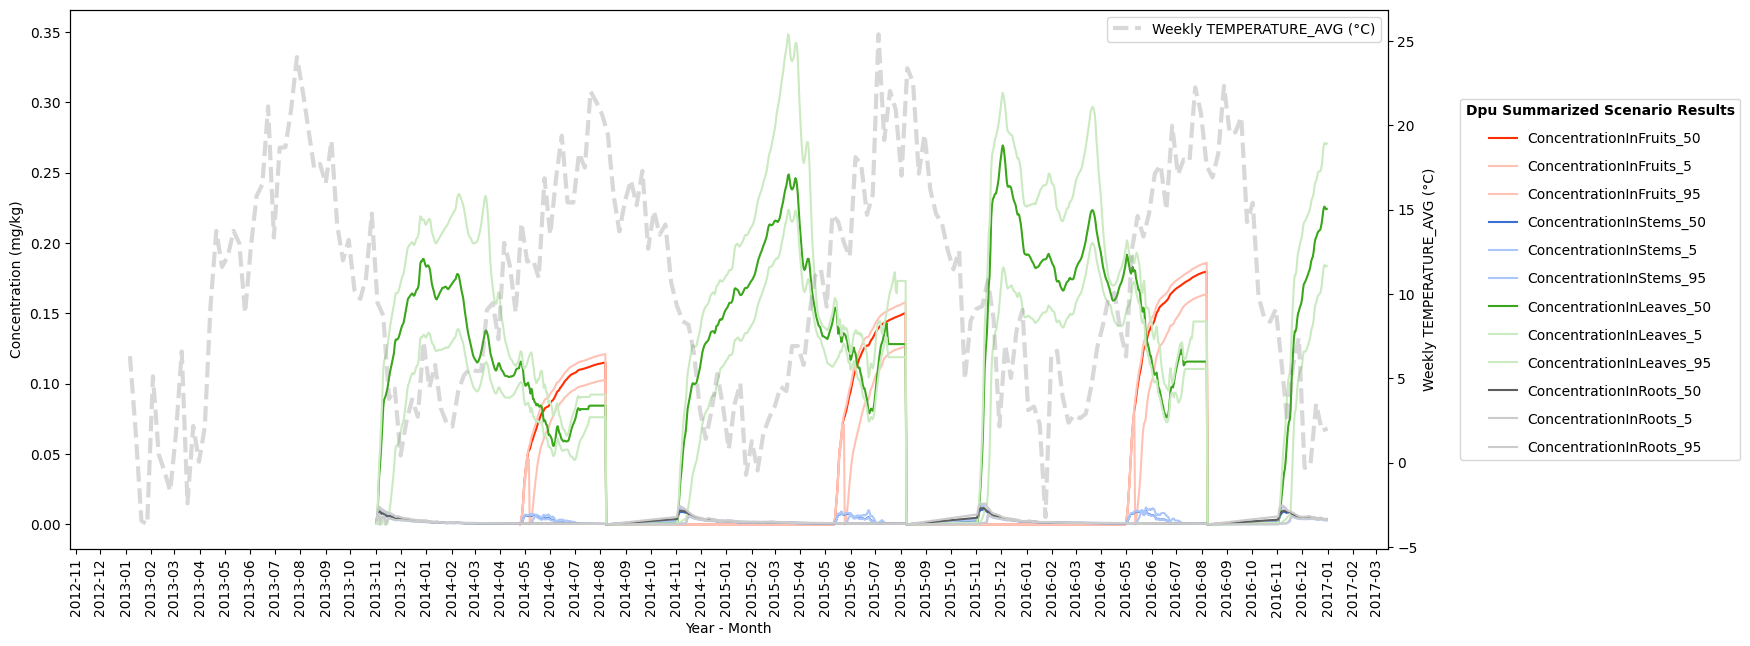

In [426]:
# Plot using Seaborn
plt.figure(figsize=(17, 7))  # Adjust figure size if needed
seaborn.lineplot(data=melted_df, x='date', y='value', hue='variable', palette = palettex, alpha=1)#palette=seaborn.set_palette(palettex, n_colors=10000))#, alpha=0.9) #palette=seaborn.color_palette(palette, 9)


# Set x-axis major locator to show only the first day of each month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))

# Set x-axis date format to show both month and year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


plt.xlabel('Year - Month')

first_key = next(iter(filtered_units))
first_value = filtered_units[first_key][0]
plt.ylabel('Concentration ('+first_value+')')

leg = plt.legend(title=group_name(first_key)+' Summarized Scenario Results',bbox_to_anchor=(1.05, 0.5), loc='center left', labelspacing=1)
leg.get_title().set_fontweight('bold')

# Rotate x-axis labels 
plt.xticks(rotation=90)



weather_key_plot = next(iter(weather_dict))
weather_key_plotn = subdata_name(weather_key_plot)
weather_plot_value = weather_dict[weather_key_plot][0]
ax2 = plt.gca().twinx()
seaborn.lineplot(data=weekly_avg_weather,  x='Date',y=weather_key_plotn,ax=ax2, color='gray',  linestyle='--', linewidth=3, alpha=0.3, label = "Weekly "+weather_key_plotn+" ("+weather_plot_value+")")
plt.ylabel("Weekly "+weather_key_plotn+" ("+weather_plot_value+")")
plt.show()

MAKE THE SAME PLOT WITHOUT WEATHER DATA INCLUDED ON THE SECONDARY Y-AXIS

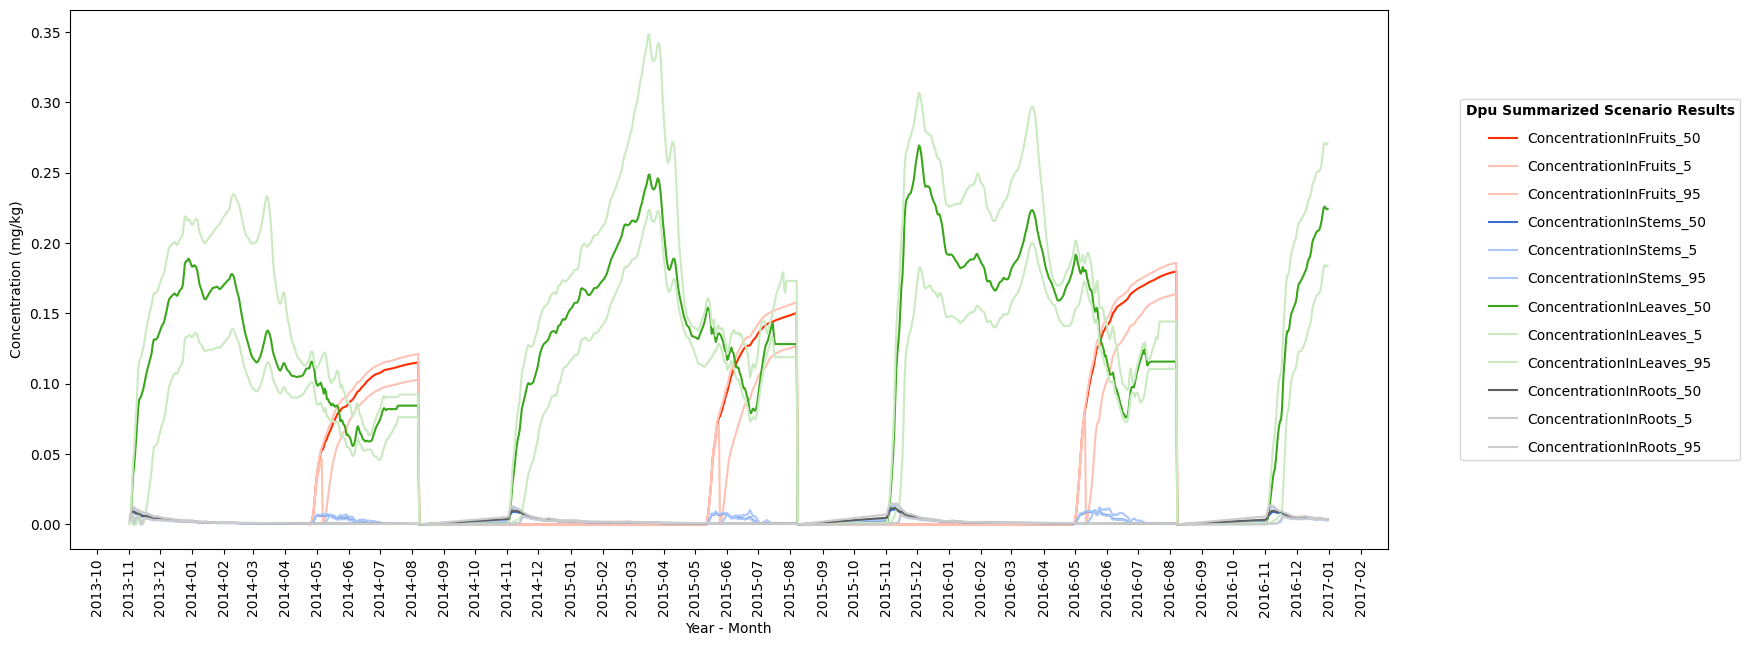

In [427]:
# Plot using Seaborn
plt.figure(figsize=(17, 7))  # Adjust figure size if needed
seaborn.lineplot(data=melted_df, x='date', y='value', hue='variable', palette = palettex)


# Set x-axis major locator to show only the first day of each month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))


plt.xlabel('Year - Month')

first_key = next(iter(filtered_units))
first_value = filtered_units[first_key][0]
plt.ylabel('Concentration ('+first_value+')')

leg = plt.legend(title=group_name(first_key)+' Summarized Scenario Results',bbox_to_anchor=(1.05, 0.5), loc='center left', labelspacing=1)
leg.get_title().set_fontweight('bold')

# Rotate x-axis labels 
plt.xticks(rotation=90)


plt.show()

In [428]:
print(single_field_plot)

Empty DataFrame
Columns: [date, field_idx, time_idx, variable, value]
Index: []


In [ ]:
# # Plot using Seaborn
# plt.figure(figsize=(17, 7))  # Adjust figure size if needed
# seaborn.lineplot(data=single_field_plot, x='date', y='value', hue='variable', palette = palette_single_field)


# # Set x-axis major locator to show only the first day of each month
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))


# plt.xlabel('Year - Month')

# first_key = next(iter(filtered_units))
# first_value = filtered_units[first_key][0]
# plt.ylabel('Concentration ('+first_value+')')

# # leg = plt.legend(title=group_name(first_key)+' Summarized Scenario Results',bbox_to_anchor=(1.05, 0.5), loc='center left', labelspacing=1)
# # leg.get_title().set_fontweight('bold')

# # Rotate x-axis labels 
# plt.xticks(rotation=90)


# plt.show()

In [430]:
# seaborn.set_theme(style="darkgrid")


# # Plot each year's time series in its own facet
# g = seaborn.relplot(
#     data=test3,
#     x="month", y="concentrat", col="year", hue="year",
#     kind="line", palette="crest", linewidth=4, zorder=5,
#     col_wrap=3, height=5, aspect=1.5, legend=False,
# )

# for year, ax in g.axes_dict.items():

#     # Add the title as an annotation within the plot
#     ax.text(.1, .85, year, transform=ax.transAxes, fontweight="bold")

# g.set_titles("")
# g.set_axis_labels("", "Concentration in Fruit")
# g.tight_layout()

In [431]:
### Uncomment and use if plots returning weird errors to reset variables and rerun full script

#%reset -f

##     CONDITIONAL OUTPUT FILE WRITING - BASED ON USER SPECIFIED ANSWERS AT TOP

In [432]:
current_date = datetime.now().strftime("%Y%m%d")

In [433]:
# Output file names
dataset_raw_file = output_folder+"dataset_raw_"+current_date
dataset_summarized_file = output_folder+"dataset_summarized_"+current_date
weather_raw_file = output_folder+"weather_raw_"+current_date
weather_summarized_file = output_folder+"weather_summarized_"+current_date

#sheet names
dataset_raw_sheet = "Dataset Raw"
dataset_summarized_sheet = "Dataset Summarized"
weather_raw_sheet = "Weather Raw"
weather_summarized_sheet = "Weather Summarized"

nan_rep = "NaN"



if output_format == ".xlsx":
    if output_tables == "raw":
        writer = pandas.ExcelWriter(dataset_raw_file + ".xlsx", engine='xlsxwriter')
        merged_df.to_excel(writer, sheet_name=dataset_raw_sheet, index=False, na_rep=nan_rep)
        print("Raw data saved as xlsx in this folder: "+output_folder)
        if weather_output == "yes":
            filtered_weather.to_excel(writer, sheet_name=weather_raw_sheet, index=False, na_rep=nan_rep)
    
    elif output_tables == "summarized":
        writer = pandas.ExcelWriter(dataset_summarized_file + ".xlsx", engine='xlsxwriter')
        stats.to_excel(writer, sheet_name=dataset_summarized_sheet, index=False, na_rep=nan_rep)
        print("Summarized data saved as xlsx in this folder: "+output_folder)
        if weather_output == "yes":
            weather_merged2.to_excel(writer, sheet_name=weather_summarized_sheet, index=False, na_rep=nan_rep)

    writer.close()

elif output_format == ".csv":
    if output_tables == "raw":
        merged_df.to_csv(f"{dataset_raw_file}.csv", index=False, na_rep=nan_rep)
        print("Raw data saved as csv in this folder: "+output_folder)
        if weather_output == "yes":
            filtered_weather.to_csv(f"{weather_raw_file}.csv", index=False, na_rep=nan_rep)
    
    elif output_tables == "summarized":
        stats.to_csv(f"{dataset_summarized_file}.csv", index=False, na_rep=nan_rep)
        print("Summarized data saved as csv in this folder: "+output_folder)
        if weather_output == "yes":
            weather_merged2.to_csv(f"{weather_summarized_file}.csv", index=False, na_rep=nan_rep)

elif output_format == "none":
    pass  

else:
    print("Invalid output format selected.")